# Notebook13 — Multi-Omics Latent State Simulation

---

## Goal of Notebook13

Notebook13 adds a multi-omics latent state layer to the virtual CHO CLD simulator.

Previous notebooks modeled:

- clone productivity
- aggressive clone filtering
- process optimization
- glycosylation-quality coupling
- Pareto optimization
- biological calibration
- process/metabolite burden realism

Notebook13 now introduces hidden biological state programs that approximate:

- transcriptomics
- proteomics
- metabolomics
- stress adaptation
- secretion burden
- cellular robustness

The goal is not to reproduce real sequencing or proteomics data.

Instead, the goal is to create biologically meaningful latent cellular programs that explain why some clone × process candidates are robust, while others are fragile.

---

## Why multi-omics matters

Real CHO cells are not controlled by one variable.

A clone’s final performance depends on coordinated biological systems:

- gene-expression programs
- protein-folding capacity
- ER stress response
- mitochondrial/metabolic efficiency
- nutrient utilization
- glycosylation machinery
- stress adaptation

These hidden systems influence:

- productivity
- aggregation
- glycosylation
- stability
- process robustness
- manufacturability

Notebook13 approximates these systems using latent omics-like variables.

---

## What this notebook adds

Notebook13 creates three major omics-inspired layers.

### 1. Transcriptomic programs

These approximate coordinated gene-expression modules:

- secretion program
- stress response program
- energy metabolism program
- growth/proliferation program

### 2. Proteomic programs

These approximate functional protein machinery:

- secretory capacity
- folding capacity
- mitochondrial activity
- proteostasis balance

### 3. Metabolomic programs

These approximate metabolic state:

- glycolytic shift
- oxidative metabolism
- nutrient pressure
- overflow metabolism

Together, these form a synthetic multi-omics matrix.

---

## Digital twin meaning

This notebook moves the simulator closer to a digital twin because it introduces hidden biological states.

Instead of modeling only:

clone → output

the simulator now models:

clone + process → hidden cellular state → output

This is closer to real biology.

---

## Important interpretation

The variables in this notebook are biologically inspired latent approximations.

They are not real RNA-seq, proteomics, or metabolomics measurements.

Future versions can replace or calibrate these latent variables using public CHO datasets such as:

- NISTCHO
- CHO-K1 transcriptomics
- CHO-S fed-batch datasets
- GEO gene-expression datasets
- PRIDE proteomics datasets
- Metabolomics Workbench datasets

For now, Notebook13 provides the multi-omics structure needed for future empirical anchoring.

## Section 1 — Import libraries

This section loads the required Python libraries.

The notebook uses:

- pandas and numpy for data processing
- matplotlib for visualization
- scikit-learn for scaling, PCA, clustering, and t-SNE

In [7]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

## Section 2 — Load Notebook12 process-burden output

Notebook13 builds directly on Notebook12.

Notebook12 generated the process-burden realism dataset, including:

- productivity signal
- lactate burden
- ammonia burden
- oxidative stress
- ER stress
- nutrient depletion pressure
- dynamic failure risk
- process robustness
- burden-aware rescue score

These variables provide the biological foundation for constructing multi-omics latent states.

In [8]:
# --------------------------------------------------
# Section 2 — Load Notebook12 output
# --------------------------------------------------

def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()
    start = Path(start).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "synthetic").exists():
            return p

    raise FileNotFoundError("Could not find project root containing data/synthetic")


ROOT = find_project_root()

scenario = "legacy"
n_clones = 5000

INPUT_PATH = (
    ROOT
    / "data"
    / "synthetic"
    / "process"
    / f"notebook12_process_burden_simulation_{n_clones}_{scenario}.csv"
)

df = pd.read_csv(INPUT_PATH)

print("ROOT:", ROOT)
print("INPUT_PATH:", INPUT_PATH)
print("df shape:", df.shape)

display(df.head())

ROOT: /Users/sang/CLD_ML_PIPELINE
INPUT_PATH: /Users/sang/CLD_ML_PIPELINE/data/synthetic/process/notebook12_process_burden_simulation_5000_legacy.csv
df shape: (92, 66)


,clone_id,process_condition,pareto_rank,candidate_archetype,weighted_multiobj_score,obj_productivity,obj_stability,obj_quality,obj_risk_safety,obj_rescue_value,...,lactate_burden,ammonia_burden,oxidative_stress,er_stress_burden,nutrient_depletion_pressure,integrated_process_burden,dynamic_failure_risk,process_robustness,burden_archetype,burden_aware_rescue_score
0,CLONE_4625,stress_minimized,1.0,Rescue-value,0.832599,1.000000,0.830653,0.698502,0.612287,1.000000,...,0.662715,0.410966,0.370666,0.668067,0.656448,0.554353,0.425753,Stable,Intermediate,0.584229
1,CLONE_4878,stress_minimized,2.0,Balanced,0.730900,0.796817,0.692042,0.663813,0.731984,0.776958,...,0.469333,0.385610,0.447586,0.495796,0.541452,0.465673,0.306054,Stable,Intermediate,0.637614
2,CLONE_3895,mild_temp_shift,3.0,Risk-safe,0.603442,0.011834,0.822675,0.986077,1.000000,0.388383,...,0.187032,0.138156,0.270320,0.212050,0.152063,0.194924,0.078469,Robust,Balanced-Resilient,0.789026
3,CLONE_3895,balanced_feed,4.0,Quality-led,0.601918,0.011834,0.822675,0.989642,0.983893,0.388383,...,0.196538,0.150167,0.204714,0.165631,0.219841,0.184667,0.036206,Robust,Balanced-Resilient,0.794791
4,CLONE_3007,stress_minimized,5.0,Stability-led,0.601847,0.000540,0.992249,0.926534,0.967398,0.264918,...,0.000000,0.155809,0.162559,0.136178,0.225450,0.131536,0.183182,Robust,Intermediate,0.518161


## Section 3 — Create Notebook13-compatible biological aliases

Notebook12 contains real project-specific column names.

Notebook13 needs simplified biology-oriented aliases.

This section creates those aliases without changing upstream files.

Examples:

- process_galactosylation_level → galactosylation_index
- process_sialylation_capacity → sialylation_index
- integrated_process_burden → integrated_burden
- dynamic_failure_risk → stress_failure_risk
- burden_aware_rescue_score → rescue_potential_score

The notebook also derives two additional latent proxies:

- mitochondrial_capacity
- growth_rate

These are not measured variables. They are simulated biological proxies derived from stress adaptation, nutrient utilization, lactate, ammonia, and oxidative stress.

In [9]:
# --------------------------------------------------
# Section 3 — Create Notebook13-compatible aliases
# --------------------------------------------------

required_cols = [
    "productivity_signal",
    "process_galactosylation_level",
    "process_sialylation_capacity",
    "integrated_process_burden",
    "dynamic_failure_risk",
    "burden_aware_rescue_score",
    "stress_adaptation_capacity",
    "nutrient_utilization_efficiency",
    "oxidative_stress",
    "lactate_burden",
    "ammonia_burden",
    "er_stress_burden",
    "nutrient_depletion_pressure",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns from Notebook12 output: {missing}")


df["galactosylation_index"] = df["process_galactosylation_level"]
df["sialylation_index"] = df["process_sialylation_capacity"]
df["integrated_burden"] = df["integrated_process_burden"]
df["stress_failure_risk"] = df["dynamic_failure_risk"]
df["rescue_potential_score"] = df["burden_aware_rescue_score"]

df["mitochondrial_capacity"] = (
    0.50 * df["stress_adaptation_capacity"]
    + 0.30 * df["nutrient_utilization_efficiency"]
    + 0.20 * (1 - df["oxidative_stress"])
).clip(0, 1)

df["growth_rate"] = (
    0.45 * (1 - df["lactate_burden"])
    + 0.30 * (1 - df["ammonia_burden"])
    + 0.25 * df["stress_adaptation_capacity"]
).clip(0, 1)

alias_cols = [
    "productivity_signal",
    "galactosylation_index",
    "sialylation_index",
    "integrated_burden",
    "stress_failure_risk",
    "rescue_potential_score",
    "mitochondrial_capacity",
    "growth_rate",
]

display(df[alias_cols].describe())
display(df[alias_cols].head())

,productivity_signal,galactosylation_index,sialylation_index,integrated_burden,stress_failure_risk,rescue_potential_score,mitochondrial_capacity,growth_rate
count,9.200000e+01,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000
mean,3.727049e-07,0.705708,0.660519,0.304636,0.320337,0.604857,0.651803,0.697948
std,7.524082e-07,0.186275,0.204430,0.102507,0.123528,0.071143,0.105052,0.097843
min,2.498445e-08,0.250485,0.288012,0.056264,0.000000,0.425795,0.397197,0.469394
25%,8.950082e-08,0.596822,0.470016,0.221207,0.244631,0.558909,0.588435,0.623154
50%,1.937304e-07,0.723012,0.652346,0.308754,0.318254,0.607900,0.654470,0.691388
75%,3.636152e-07,0.840422,0.804557,0.380547,0.403930,0.652658,0.705068,0.771538
max,5.537450e-06,1.000000,1.000000,0.554353,0.588827,0.794791,0.915844,0.905224


,productivity_signal,galactosylation_index,sialylation_index,integrated_burden,stress_failure_risk,rescue_potential_score,mitochondrial_capacity,growth_rate
0,5.537450e-06,0.769200,0.646254,0.554353,0.425753,0.584229,0.705865,0.510702
1,4.417263e-06,0.618129,0.457032,0.465673,0.306054,0.637614,0.693457,0.610391
2,8.950082e-08,0.840210,1.000000,0.194924,0.078469,0.789026,0.863765,0.874389
3,8.950082e-08,0.858233,1.000000,0.184667,0.036206,0.794791,0.876886,0.866508
4,2.723450e-08,0.720060,0.898546,0.131536,0.183182,0.518161,0.594564,0.814581


## Section 4 — Simulate transcriptomic programs

This section creates synthetic transcriptomic programs.

These programs approximate coordinated gene-expression modules.

The transcriptomic layer includes:

- tx_secretion_program
- tx_stress_program
- tx_energy_metabolism
- tx_growth_program

Biological meaning:

- secretion program increases with productivity and glycan maturation
- stress program increases with oxidative and ER stress
- energy metabolism improves with mitochondrial capacity and decreases with lactate burden
- growth program improves with growth rate and decreases with failure risk

In [10]:
# --------------------------------------------------
# Section 4 — Transcriptomic program simulation
# --------------------------------------------------

rng = np.random.default_rng(42)

df["tx_secretion_program"] = (
    0.45 * df["productivity_signal"]
    + 0.30 * df["galactosylation_index"]
    - 0.25 * df["integrated_burden"]
    + rng.normal(0, 0.08, len(df))
)

df["tx_stress_program"] = (
    0.55 * df["oxidative_stress"]
    + 0.40 * df["er_stress_burden"]
    + rng.normal(0, 0.08, len(df))
)

df["tx_energy_metabolism"] = (
    0.50 * df["mitochondrial_capacity"]
    - 0.35 * df["lactate_burden"]
    + rng.normal(0, 0.08, len(df))
)

df["tx_growth_program"] = (
    0.40 * df["growth_rate"]
    - 0.30 * df["stress_failure_risk"]
    + rng.normal(0, 0.08, len(df))
)

tx_cols = [
    "tx_secretion_program",
    "tx_stress_program",
    "tx_energy_metabolism",
    "tx_growth_program",
]

display(df[tx_cols].describe())

,tx_secretion_program,tx_stress_program,tx_energy_metabolism,tx_growth_program
count,92.000000,92.000000,92.000000,92.000000
mean,0.136802,0.309346,0.240140,0.186762
std,0.087384,0.143280,0.104891,0.108581
min,-0.060691,-0.014668,-0.019696,-0.100334
25%,0.073422,0.197041,0.163153,0.114548
50%,0.138460,0.317654,0.246557,0.183097
75%,0.190039,0.405739,0.302798,0.245400
max,0.386442,0.681854,0.499180,0.421506


## Section 5 — Simulate proteomic programs

This section simulates proteomic state variables.

Proteomic states represent functional cellular machinery.

The proteomic layer includes:

- prot_secretory_capacity
- prot_folding_capacity
- prot_mito_activity
- prot_proteostasis_balance

Biological meaning:

- secretory capacity reflects secretion machinery activity
- folding capacity reflects ER/chaperone ability
- mitochondrial activity reflects energy-producing machinery
- proteostasis balance reflects whether protein production and folding remain balanced

In [11]:
# --------------------------------------------------
# Section 5 — Proteomic program simulation
# --------------------------------------------------

df["prot_secretory_capacity"] = (
    0.60 * df["tx_secretion_program"]
    - 0.25 * df["er_stress_burden"]
    + rng.normal(0, 0.07, len(df))
)

df["prot_folding_capacity"] = (
    0.50 * df["tx_stress_program"]
    + 0.35 * df["rescue_potential_score"]
    - 0.15 * df["er_stress_burden"]
    + rng.normal(0, 0.07, len(df))
)

df["prot_mito_activity"] = (
    0.70 * df["tx_energy_metabolism"]
    + 0.20 * df["mitochondrial_capacity"]
    + rng.normal(0, 0.07, len(df))
)

df["prot_proteostasis_balance"] = (
    0.45 * df["prot_folding_capacity"]
    + 0.35 * df["prot_secretory_capacity"]
    - 0.30 * df["er_stress_burden"]
    + rng.normal(0, 0.07, len(df))
)

prot_cols = [
    "prot_secretory_capacity",
    "prot_folding_capacity",
    "prot_mito_activity",
    "prot_proteostasis_balance",
]

display(df[prot_cols].describe())

,prot_secretory_capacity,prot_folding_capacity,prot_mito_activity,prot_proteostasis_balance
count,92.000000,92.000000,92.000000,92.000000
mean,0.001025,0.314281,0.290756,0.033134
std,0.095051,0.096462,0.105055,0.090161
min,-0.186958,0.101744,0.060790,-0.200195
25%,-0.067729,0.256949,0.216400,-0.030006
50%,-0.002655,0.318210,0.282700,0.032859
75%,0.063445,0.366812,0.355100,0.092702
max,0.230973,0.590683,0.517354,0.223896


## Section 6 — Simulate metabolomic programs

This section simulates metabolomic state variables.

The metabolomic layer includes:

- met_glycolytic_shift
- met_oxidative_state
- met_nutrient_pressure
- met_overflow_burden

Biological meaning:

- glycolytic shift increases with lactate and ammonia burden
- oxidative state reflects mitochondrial function minus oxidative stress
- nutrient pressure reflects nutrient depletion
- overflow burden integrates lactate, ammonia, and nutrient pressure

In [12]:
# --------------------------------------------------
# Section 6 — Metabolomic program simulation
# --------------------------------------------------

df["met_glycolytic_shift"] = (
    0.60 * df["lactate_burden"]
    + 0.30 * df["ammonia_burden"]
    + rng.normal(0, 0.06, len(df))
)

df["met_oxidative_state"] = (
    0.55 * df["mitochondrial_capacity"]
    - 0.35 * df["oxidative_stress"]
    + rng.normal(0, 0.06, len(df))
)

df["met_nutrient_pressure"] = (
    0.65 * df["nutrient_depletion_pressure"]
    + 0.20 * df["integrated_burden"]
    + rng.normal(0, 0.06, len(df))
)

df["met_overflow_burden"] = (
    0.40 * df["lactate_burden"]
    + 0.30 * df["ammonia_burden"]
    + 0.30 * df["nutrient_depletion_pressure"]
    + rng.normal(0, 0.06, len(df))
)

met_cols = [
    "met_glycolytic_shift",
    "met_oxidative_state",
    "met_nutrient_pressure",
    "met_overflow_burden",
]

display(df[met_cols].describe())

,met_glycolytic_shift,met_oxidative_state,met_nutrient_pressure,met_overflow_burden
count,92.000000,92.000000,92.000000,92.000000
mean,0.259505,0.235341,0.208457,0.278334
std,0.111907,0.115282,0.091594,0.109755
min,0.028136,-0.008583,-0.084365,0.009155
25%,0.181455,0.148464,0.145402,0.197772
50%,0.260885,0.243311,0.210419,0.282303
75%,0.324910,0.311713,0.271236,0.352445
max,0.567585,0.510969,0.518487,0.555266


## Section 7 — Build integrated omics matrix

This section combines all simulated transcriptomic, proteomic, and metabolomic variables.

The result is a synthetic multi-omics matrix.

Each row represents one clone × process candidate.

Each column represents one hidden biological program.

In [13]:
# --------------------------------------------------
# Section 7 — Integrated omics matrix
# --------------------------------------------------

omics_cols = tx_cols + prot_cols + met_cols

omics_df = df[omics_cols].copy()

scaler = StandardScaler()
omics_scaled = scaler.fit_transform(omics_df)

print("Omics matrix shape:", omics_df.shape)

display(omics_df.head())

Omics matrix shape: (92, 12)


,tx_secretion_program,tx_stress_program,tx_energy_metabolism,tx_growth_program,prot_secretory_capacity,prot_folding_capacity,prot_mito_activity,prot_proteostasis_balance,met_glycolytic_shift,met_oxidative_state,met_nutrient_pressure,met_overflow_burden
0,0.116551,0.437229,0.155283,0.015510,-0.082924,0.344858,0.270620,-0.097870,0.567585,0.331344,0.518487,0.555266
1,-0.014176,0.438113,0.305322,0.063347,-0.073348,0.309516,0.494872,-0.045068,0.445703,0.064376,0.393058,0.366546
2,0.263368,0.098509,0.381080,0.421506,0.105808,0.182337,0.433412,0.098537,0.056474,0.404215,0.144979,0.099176
3,0.286548,0.063076,0.271697,0.356761,0.223549,0.139761,0.344069,-0.029702,0.028136,0.504324,0.145543,0.128355
4,0.027051,0.038063,0.187829,0.309289,0.042162,0.101744,0.197646,0.031195,0.106847,0.202448,0.162880,0.117508


## Section 8 — PCA latent omics compression

PCA compresses the multi-omics matrix into a smaller number of latent biological axes.

These latent axes represent dominant systems-level cellular programs.

For example:

- one axis may represent stress burden
- one axis may represent productivity/secretion
- one axis may represent metabolic efficiency
- one axis may represent quality adaptation

In [14]:
# --------------------------------------------------
# Section 8 — PCA latent omics compression
# --------------------------------------------------

n_components = min(4, omics_scaled.shape[1], omics_scaled.shape[0])

pca = PCA(n_components=n_components)

omics_latent = pca.fit_transform(omics_scaled)

explained = pca.explained_variance_ratio_

print("Explained variance ratios:")
for i, ev in enumerate(explained, start=1):
    print(f"omics_latent_{i}: {ev:.3f}")

for i in range(n_components):
    df[f"omics_latent_{i+1}"] = omics_latent[:, i]

loading_df = pd.DataFrame(
    pca.components_.T,
    index=omics_cols,
    columns=[f"omics_latent_{i+1}" for i in range(n_components)]
)

display(loading_df.round(3))

Explained variance ratios:
omics_latent_1: 0.374
omics_latent_2: 0.158
omics_latent_3: 0.123
omics_latent_4: 0.095


,omics_latent_1,omics_latent_2,omics_latent_3,omics_latent_4
tx_secretion_program,-0.166,0.532,-0.002,0.246
tx_stress_program,0.383,0.023,0.336,-0.010
tx_energy_metabolism,-0.262,-0.294,0.496,0.080
tx_growth_program,-0.334,-0.029,0.106,0.060
prot_secretory_capacity,-0.206,0.479,-0.099,0.406
prot_folding_capacity,0.239,0.293,0.484,-0.175
prot_mito_activity,-0.213,-0.331,0.436,0.312
prot_proteostasis_balance,-0.121,0.432,0.432,-0.202
met_glycolytic_shift,0.395,0.037,0.039,0.231
met_oxidative_state,-0.299,-0.007,0.017,0.325


## Section 9 — Visualize PCA latent omics space

This plot shows the first two omics latent axes.

Each point represents a clone × process candidate.

The plot helps identify whether candidates separate into biological state regions.

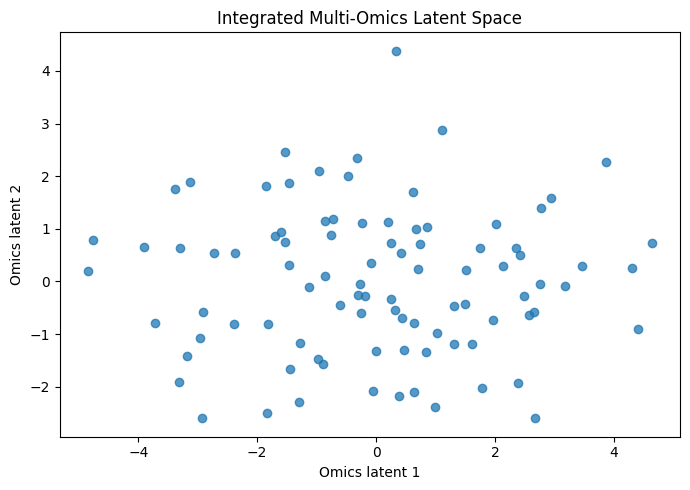

In [15]:
# --------------------------------------------------
# Section 9 — PCA latent space visualization
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    df["omics_latent_1"],
    df["omics_latent_2"],
    alpha=0.75
)

plt.xlabel("Omics latent 1")
plt.ylabel("Omics latent 2")
plt.title("Integrated Multi-Omics Latent Space")

plt.tight_layout()
plt.show()

## Section 10 — Cellular state clustering

This section clusters clone × process candidates in omics latent space.

The goal is to identify emergent biological states.

Examples may include:

- balanced resilient states
- hypersecretory stressed states
- metabolically burdened states
- quality-adapted states

In [16]:
# --------------------------------------------------
# Section 10 — Cellular state clustering
# --------------------------------------------------

n_clusters = min(4, max(2, len(df) // 10))

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

df["cellular_state"] = kmeans.fit_predict(omics_latent)

sil_score = silhouette_score(omics_latent, df["cellular_state"])

print("Number of cellular states:", n_clusters)
print("Silhouette score:", round(sil_score, 3))

display(df["cellular_state"].value_counts().sort_index())

Number of cellular states: 4
Silhouette score: 0.208


cellular_state
0    22
1    29
2    24
3    17
Name: count, dtype: int64

## Section 11 — Characterize cellular states

This section summarizes each cellular state using biologically meaningful metrics.

This helps interpret what each cluster represents.

In [17]:
# --------------------------------------------------
# Section 11 — Characterize cellular states
# --------------------------------------------------

state_summary_cols = [
    "productivity_signal",
    "integrated_burden",
    "stress_failure_risk",
    "galactosylation_index",
    "sialylation_index",
    "rescue_potential_score",
    "mitochondrial_capacity",
    "growth_rate",
    "tx_stress_program",
    "prot_proteostasis_balance",
    "met_overflow_burden",
]

state_summary = (
    df
    .groupby("cellular_state")[state_summary_cols]
    .mean()
    .round(3)
)

display(state_summary)

,productivity_signal,integrated_burden,stress_failure_risk,galactosylation_index,sialylation_index,rescue_potential_score,mitochondrial_capacity,growth_rate,tx_stress_program,prot_proteostasis_balance,met_overflow_burden
cellular_state,,,,,,,,,,,
0,0.0,0.421,0.444,0.653,0.632,0.575,0.595,0.590,0.490,0.024,0.398
1,0.0,0.321,0.299,0.688,0.663,0.592,0.628,0.687,0.286,-0.041,0.276
2,0.0,0.280,0.339,0.810,0.629,0.608,0.650,0.709,0.285,0.108,0.276
3,0.0,0.160,0.170,0.658,0.736,0.661,0.769,0.842,0.149,0.065,0.131


## Section 12 — Assign biological archetype labels

This section converts numerical cellular states into interpretable biological archetypes.

These labels help communicate what each omics state means.

The labels are heuristic but biologically motivated.

In [18]:
# --------------------------------------------------
# Section 12 — Assign biological archetype labels
# --------------------------------------------------

state_labels = {}

prod_q75 = df["productivity_signal"].quantile(0.75)

for state, row in state_summary.iterrows():

    if (
        row["productivity_signal"] >= prod_q75
        and row["integrated_burden"] >= 0.40
    ):
        label = "Hypersecretory-Stressed"

    elif (
        row["stress_failure_risk"] < 0.30
        and row["integrated_burden"] < 0.30
        and row["growth_rate"] > 0.60
    ):
        label = "Balanced-Resilient"

    elif (
        row["galactosylation_index"] > 0.65
        and row["sialylation_index"] > 0.50
    ):
        label = "Quality-Adapted"

    elif (
        row["met_overflow_burden"] > 0.45
        or row["tx_stress_program"] > 0.45
    ):
        label = "Metabolic-Stress"

    else:
        label = "Intermediate-Adaptive"

    state_labels[state] = label


df["cellular_archetype"] = df["cellular_state"].map(state_labels)

archetype_table = (
    df[["cellular_state", "cellular_archetype"]]
    .drop_duplicates()
    .sort_values("cellular_state")
    .reset_index(drop=True)
)

display(archetype_table)

display(df["cellular_archetype"].value_counts())

,cellular_state,cellular_archetype
0,0,Quality-Adapted
1,1,Quality-Adapted
2,2,Quality-Adapted
3,3,Balanced-Resilient


cellular_archetype
Quality-Adapted       75
Balanced-Resilient    17
Name: count, dtype: int64

## Section 13 — t-SNE nonlinear omics visualization

t-SNE is used to visualize nonlinear structure in the omics space.

This is useful because biological states may separate nonlinearly.

Each point is colored by the assigned cellular archetype.

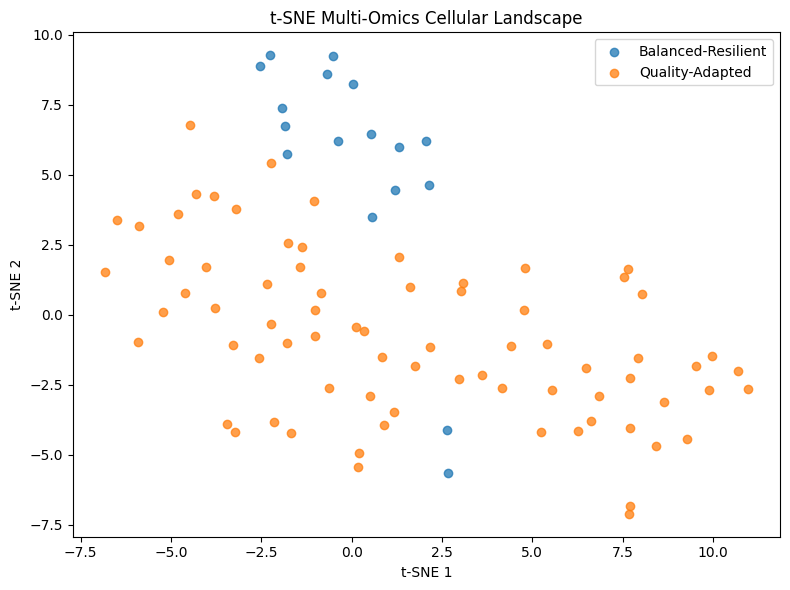

In [19]:
# --------------------------------------------------
# Section 13 — t-SNE nonlinear omics visualization
# --------------------------------------------------

perplexity = min(20, max(5, (len(df) - 1) // 3))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

tsne_result = tsne.fit_transform(omics_scaled)

df["tsne_1"] = tsne_result[:, 0]
df["tsne_2"] = tsne_result[:, 1]

plt.figure(figsize=(8, 6))

for label in sorted(df["cellular_archetype"].unique()):
    subset = df[df["cellular_archetype"] == label]

    plt.scatter(
        subset["tsne_1"],
        subset["tsne_2"],
        label=label,
        alpha=0.75
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Multi-Omics Cellular Landscape")
plt.legend()
plt.tight_layout()
plt.show()

## Section 14 — Omics-state relationship to process robustness

This section checks whether omics-derived cellular archetypes relate to process robustness.

If the simulator is coherent, fragile or stressed archetypes should show higher burden or failure risk.

Balanced archetypes should show lower burden and stronger rescue potential.

In [20]:
# --------------------------------------------------
# Section 14 — Omics-state relationship to robustness
# --------------------------------------------------

robustness_summary = (
    df
    .groupby("cellular_archetype")[
        [
            "productivity_signal",
            "integrated_burden",
            "stress_failure_risk",
            "rescue_potential_score",
            "burden_aware_rescue_score",
        ]
    ]
    .mean()
    .round(3)
    .sort_values("stress_failure_risk")
)

display(robustness_summary)

,productivity_signal,integrated_burden,stress_failure_risk,rescue_potential_score,burden_aware_rescue_score
cellular_archetype,,,,,
Balanced-Resilient,0.0,0.160,0.170,0.661,0.661
Quality-Adapted,0.0,0.337,0.354,0.592,0.592


## Section 15 — Export multi-omics latent state dataset

This section exports the Notebook13 output.

The output is saved to:

data/synthetic/omics/

This is the first notebook that produces omics-style digital-twin features.

In [21]:
# --------------------------------------------------
# Section 15 — Export outputs
# --------------------------------------------------

OUT_DIR = ROOT / "data" / "synthetic" / "omics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = (
    OUT_DIR
    / f"notebook13_multiomics_latent_state_{n_clones}_{scenario}.csv"
)

STATE_SUMMARY_PATH = (
    OUT_DIR
    / f"notebook13_cellular_state_summary_{n_clones}_{scenario}.csv"
)

LOADING_PATH = (
    OUT_DIR
    / f"notebook13_omics_pca_loadings_{n_clones}_{scenario}.csv"
)

df.to_csv(OUTPUT_PATH, index=False)
state_summary.to_csv(STATE_SUMMARY_PATH)
loading_df.to_csv(LOADING_PATH)

print("Saved:")
print(OUTPUT_PATH)
print(STATE_SUMMARY_PATH)
print(LOADING_PATH)

Saved:
/Users/sang/CLD_ML_PIPELINE/data/synthetic/omics/notebook13_multiomics_latent_state_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/omics/notebook13_cellular_state_summary_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/omics/notebook13_omics_pca_loadings_5000_legacy.csv


# Final Summary — Notebook13

Notebook13 introduced a multi-omics latent state layer into the virtual CHO CLD simulator.

The simulator now includes:

- transcriptomic program simulation
- proteomic program simulation
- metabolomic program simulation
- integrated omics matrix construction
- PCA latent omics compression
- cellular state clustering
- biological archetype labeling
- nonlinear omics landscape visualization

This notebook moves the project from:

phenotype-level process simulation

toward:

systems-biology digital twin simulation

## What this means biologically

The simulator now represents hidden cellular programs that influence:

- productivity
- secretion burden
- ER stress
- metabolic burden
- glycosylation quality
- process robustness
- rescue potential

Instead of modeling only observed output variables, the simulator now contains an intermediate hidden-state layer:

clone + process condition  
→ latent cellular state  
→ productivity / quality / robustness outcome

This is closer to how real CHO biology behaves.

## Important limitation

The omics variables in this notebook are synthetic latent approximations.

They are not real RNA-seq, proteomics, metabolomics, or glycomics measurements.

Therefore, this notebook should be interpreted as:

a systems-biology simulation framework

not as an experimentally validated multi-omics model.

## Strategic significance

Notebook13 creates the foundation for future:

- empirical CHO/NISTCHO omics anchoring
- multi-omics calibration
- active learning
- reinforcement-learning process control
- digital twin trajectory simulation
- self-driving laboratory style optimization

The project is now evolving into an integrated virtual CHO CLD and process-development simulator.